In [1]:
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
data = pd.read_csv('dataset.csv')
data.head()

,NumHAcceptors,NumHDonors,alkyl_num,frag_sym,HOMO_calc,LUMO_calc,dipole,MPI,surface_min,surface_max,...,anchor_end_PO,anchor_end_SA,anchor_end_SH,anchor_end_SiO,MetalOxide_ITO,MetalOxide_NiOx,MetalOxide_SnO2,MetalOxide_TiO2,MetalOxide_ZnO,PCE
0,2,2,2,1,-5.665071,-1.022318,1.975439,11.42494,-38.62844,53.933991,...,0,0,0,0,0,1,0,0,0,22.40
1,4,2,2,1,-5.146211,-1.007550,1.467697,12.11600,-39.79595,52.674270,...,0,0,0,0,0,1,0,0,0,21.00
2,4,2,4,1,-5.182687,-1.386859,2.954174,12.05384,-40.46879,51.108000,...,0,0,0,0,0,1,0,0,0,25.60
3,3,1,0,0,-8.070575,-1.975575,6.131034,17.92665,-35.95829,45.147690,...,0,1,0,0,0,0,0,1,0,16.54
4,3,1,0,0,-7.655580,-1.919355,3.424702,15.53109,-31.70790,57.597300,...,0,1,0,0,0,0,0,1,0,16.88


In [2]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1] - data['control_PCE']
from sklearn.model_selection import ShuffleSplit,train_test_split, GridSearchCV, KFold
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
x_train0, x_test0, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=0)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train0)
x_test = scaler.transform(x_test0)

In [3]:
import matplotlib.ticker as mticker
import matplotlib
from matplotlib.backends import backend_pdf
plt.rcParams.update({
                'font.size': 8,
                'axes.titlesize': 8,
                'axes.labelsize': 8,
                'lines.linewidth':0.75,
                'font.family': 'Helvetica',
                'pdf.fonttype': 42,
                'ps.fonttype': 42,
                'svg.fonttype': 'none'
            })

In [4]:
# Xgboost
import xgboost as xgb
param_test1 =  {'learning_rate': [0.05],
              'n_estimators': [150],
              'max_depth': [3,5], 
              'min_child_weight': [3,2], 
              'subsample': [0.6],
              'colsample_bytree': [0.4,0.6],
              'gamma': [0.1], 
               'reg_alpha': [0.05,0.1], 
               'reg_lambda': [0.01,0.05,0.1],
   }
other_params={'objective': 'reg:squarederror',
              'seed': 0,
    }
model = xgb.sklearn.XGBRegressor(**other_params)
gsearch=GridSearchCV(model,param_grid=param_test1, scoring='neg_mean_squared_error',cv=10,n_jobs=8,verbose=4)
gsearch.fit(x_train, y_train)
xgb_model = gsearch.best_estimator_
print(gsearch.best_score_)
print(gsearch.best_params_)
print(f"RMSE_train: {np.sqrt(mean_squared_error(y_train, xgb_model.predict(x_train)))}")
print(f"R_train: {stats.pearsonr(y_train, xgb_model.predict(x_train))[0]}")
print(f"RMSE_test: {np.sqrt(mean_squared_error(y_test, xgb_model.predict(x_test)))}")
print(f"R_test: {stats.pearsonr(y_test, xgb_model.predict(x_test))[0]}")

Fitting 10 folds for each of 48 candidates, totalling 480 fits
-1.9304615852919746
{'colsample_bytree': 0.4, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 2, 'n_estimators': 150, 'reg_alpha': 0.1, 'reg_lambda': 0.01, 'subsample': 0.6}
RMSE_train: 0.5771628296974158
R_train: 0.9455341709855702
RMSE_test: 0.8598096136811072
R_test: 0.30052680984260577


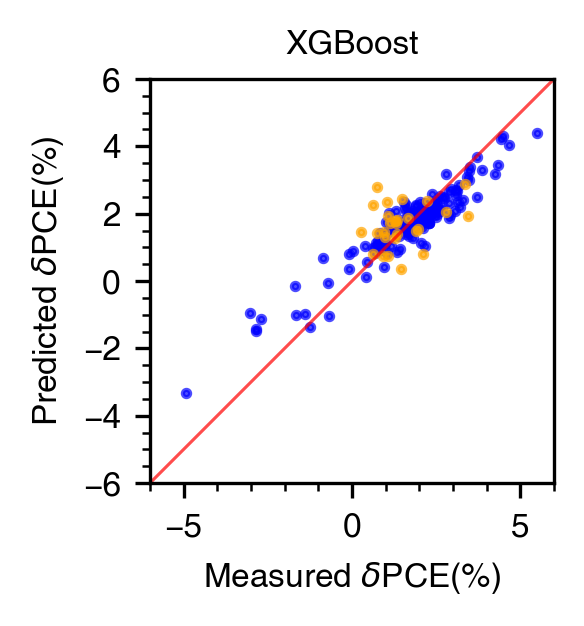

In [10]:
fig = plt.figure(dpi=300,figsize=(1.75,1.75))
ax = fig.add_subplot(111)
ax.scatter(y_train, xgb_model.predict(x_train), color='blue',alpha=0.7,s=3)
ax.scatter(y_test, xgb_model.predict(x_test), color='orange',alpha=0.7,s=3)
ax.plot([-6,6],[-6,6],'-r',alpha=0.7)
ax.set_aspect('equal')
ax.set_title('XGBoost')
ax.minorticks_on()
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
plt.xlabel(r'Measured $\delta$PCE(%)')
plt.ylabel(r'Predicted $\delta$PCE(%)')
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.show()